[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/02-data-science-stack/02_visualization_tutorial.ipynb)

# Data Visualization with Matplotlib and Seaborn

**Session 6 · the plotting toolkit the EDA notebook assumes · run it in order**

The reading describes every Matplotlib picture as a Figure that holds Axes that
hold Artists, and asks you to name the Axes you draw on rather than let
`plt.title` guess. This notebook is that rule practised on one small table:
each plot starts with `fig, ax = plt.subplots(...)` and then calls methods on
`ax`. The Seaborn cells use the shared signature from the reading, `data=`,
`x=`, `y=`, `hue=`, `ax=`, and every Seaborn figure lands in a Matplotlib Axes
you created.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
rng = np.random.default_rng(7)

df = pd.DataFrame({
    'hours_studied': rng.normal(6, 1.2, 120).clip(1, 10),
    'exam_score': rng.normal(78, 10, 120).clip(40, 100),
    'attendance': rng.normal(0.9, 0.05, 120).clip(0.7, 1.0),
    'track': rng.choice(['Vision', 'NLP', 'Robotics'], 120, p=[0.35, 0.4, 0.25])
})
df.head()

,hours_studied,exam_score,attendance,track
0,6.001476,78.893065,0.876990,Robotics
1,6.358495,72.089716,0.937160,Robotics
2,5.671035,76.813902,0.895876,Vision
3,4.931290,58.022537,0.904053,Vision
4,5.454395,66.685925,0.885464,Vision


## Figure and Axes objects

`plt.subplots()` returns the Figure and one Axes. Titles, labels and limits are
methods on the Axes, so there is no "current Axes" to guess about; in a script,
`plt.show()` opens the window, and in a notebook the figure appears on its own.

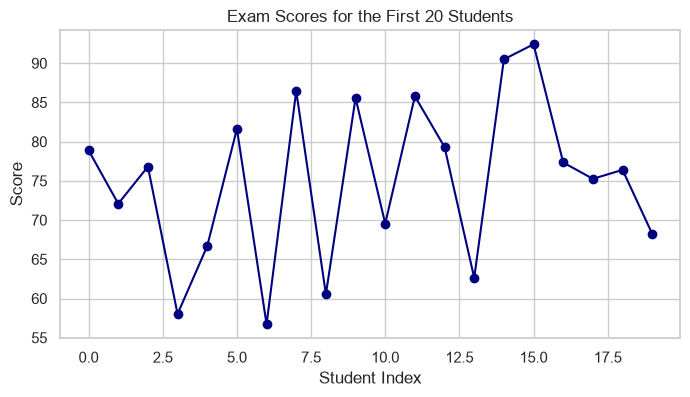

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df.index[:20], df['exam_score'].iloc[:20], marker='o', color='navy')
ax.set_title('Exam Scores for the First 20 Students')
ax.set_xlabel('Student Index')
ax.set_ylabel('Score')
plt.show()

## Scatter plot

Scatter plots reveal relationships between variables and can hint at trends or clusters.

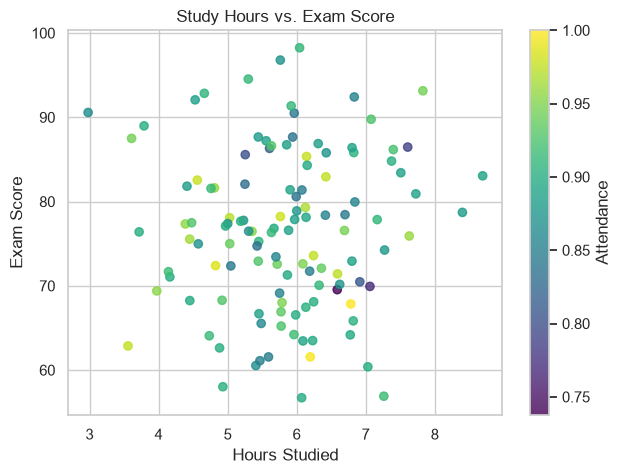

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df['hours_studied'],
    df['exam_score'],
    c=df['attendance'],
    cmap='viridis',
    alpha=0.8
)
ax.set_title('Study Hours vs. Exam Score')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
fig.colorbar(scatter, ax=ax, label='Attendance')
plt.show()

Colour can carry a category instead of a number. With Seaborn the same scatter
splits by `track` in one argument, and the legend is built for you.

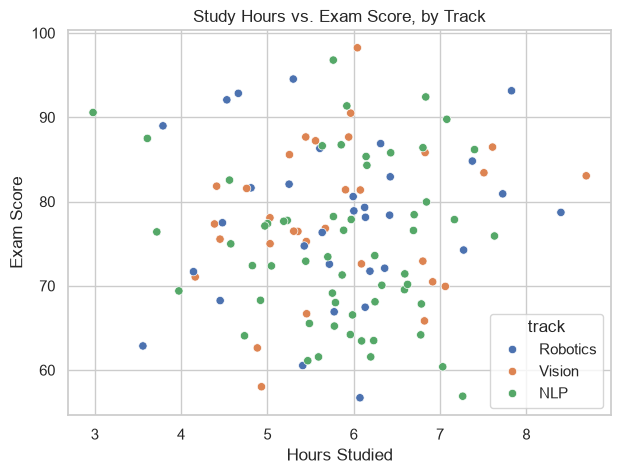

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='track', ax=ax)
ax.set_title('Study Hours vs. Exam Score, by Track')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
plt.show()

## Bar charts and histograms

Bar charts compare categories, while histograms display the distribution of a numeric feature.

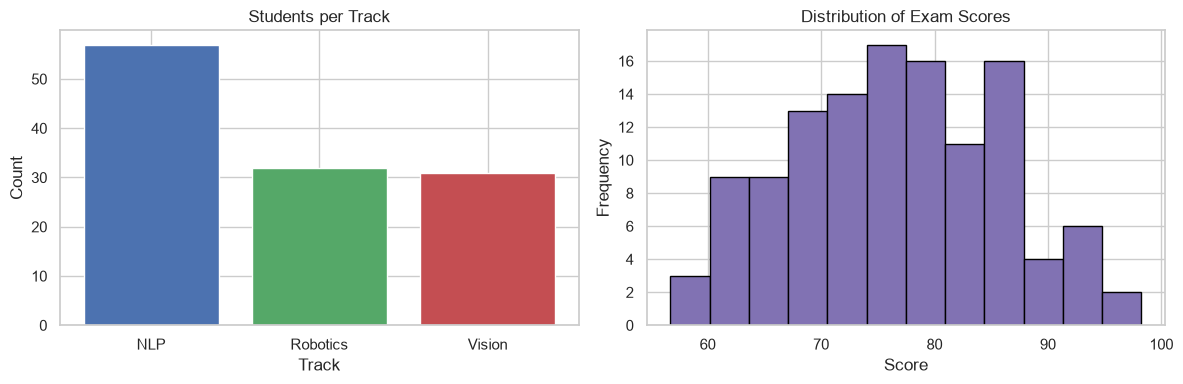

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

track_counts = df['track'].value_counts().sort_index()
axes[0].bar(track_counts.index, track_counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_title('Students per Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Count')

axes[1].hist(df['exam_score'], bins=12, color='#8172B3', edgecolor='black')
axes[1].set_title('Distribution of Exam Scores')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

fig.tight_layout()
plt.show()

## Customization with labels, styles, and legends

Clear titles, labels, legends, and color choices make plots easier to interpret.

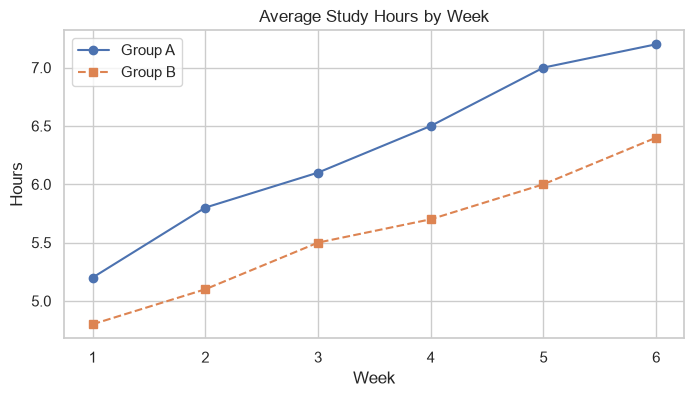

In [6]:
weekly_hours = pd.DataFrame({
    'week': np.arange(1, 7),
    'group_a': [5.2, 5.8, 6.1, 6.5, 7.0, 7.2],
    'group_b': [4.8, 5.1, 5.5, 5.7, 6.0, 6.4]
})

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(weekly_hours['week'], weekly_hours['group_a'], marker='o', label='Group A')
ax.plot(weekly_hours['week'], weekly_hours['group_b'], marker='s', linestyle='--', label='Group B')
ax.set_title('Average Study Hours by Week')
ax.set_xlabel('Week')
ax.set_ylabel('Hours')
ax.legend()
plt.show()

## Subplots for comparison

Layouts let us compare multiple features in a single figure.

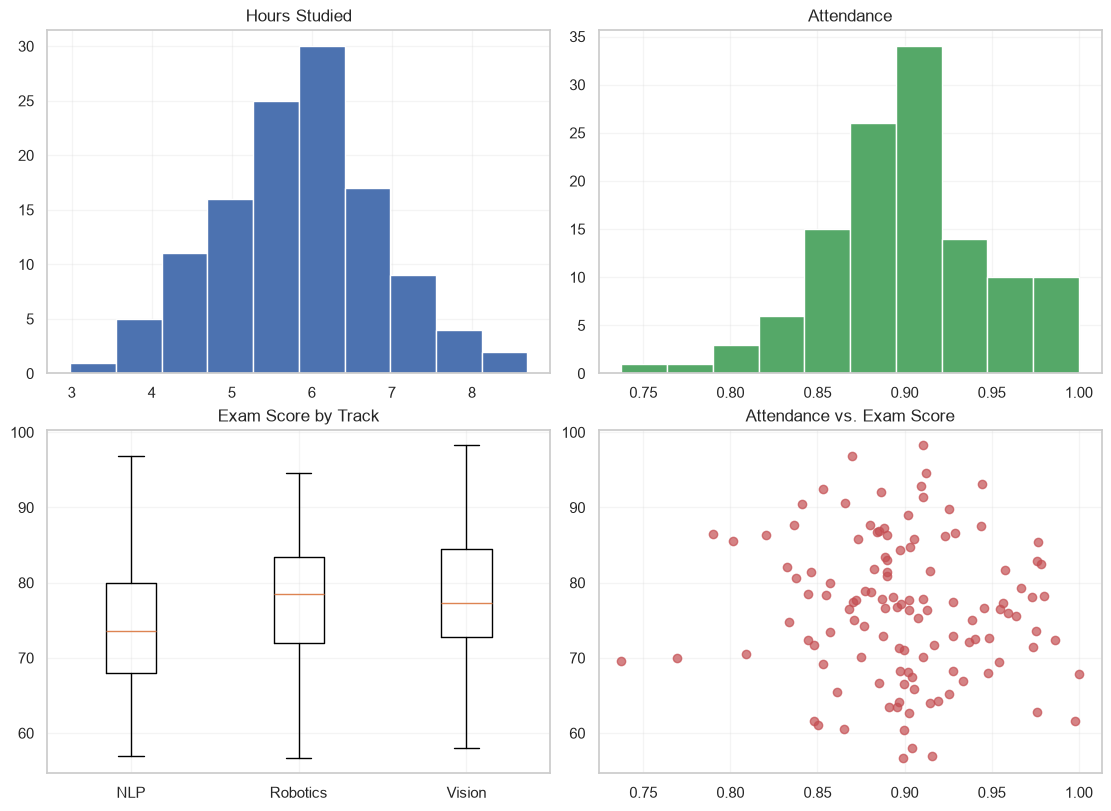

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

axes[0, 0].hist(df['hours_studied'], bins=10, color='#4C72B0')
axes[0, 0].set_title('Hours Studied')

axes[0, 1].hist(df['attendance'], bins=10, color='#55A868')
axes[0, 1].set_title('Attendance')

axes[1, 0].boxplot(
    [df.loc[df['track'] == t, 'exam_score'] for t in sorted(df['track'].unique())],
    tick_labels=sorted(df['track'].unique())
)
axes[1, 0].set_title('Exam Score by Track')

axes[1, 1].scatter(df['attendance'], df['exam_score'], alpha=0.7, color='#C44E52')
axes[1, 1].set_title('Attendance vs. Exam Score')

for ax in axes.flat:
    ax.grid(alpha=0.2)

plt.show()

## Seaborn statistical plots

Seaborn draws statistical summaries straight from a DataFrame with the pattern
`data, x, y, hue, ax`. The `hue=` argument splits a plot into coloured groups
and builds the legend; passing the same column as `x` and `hue` with
`legend=False` is how a box plot gets one colour per category.

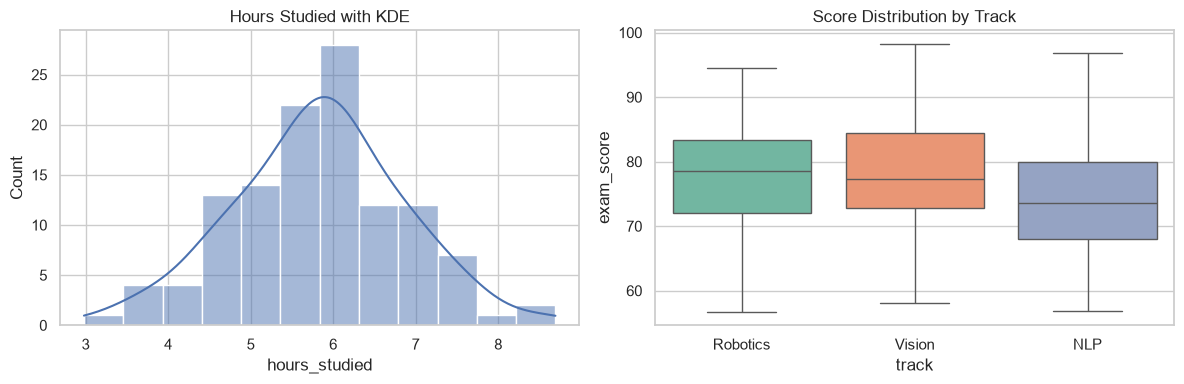

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x='hours_studied', kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Hours Studied with KDE')

sns.boxplot(data=df, x='track', y='exam_score', hue='track', legend=False,
            palette='Set2', ax=axes[1])
axes[1].set_title('Score Distribution by Track')
fig.tight_layout()
plt.show()

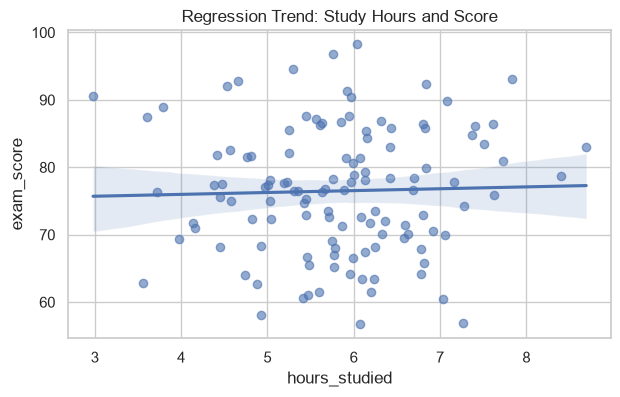

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.regplot(data=df, x='hours_studied', y='exam_score', ax=ax, scatter_kws={'alpha': 0.6})
ax.set_title('Regression Trend: Study Hours and Score')
fig.savefig('study_hours_vs_score.png', dpi=200, bbox_inches='tight')
plt.show()